In [1]:
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neural_network import MLPClassifier as NN

import math
import matplotlib as mpl
from functools import partial

from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.gaussian_process import GaussianProcessClassifier as GPC
from sklearn.gaussian_process.kernels import RBF

from dijsktra_algorithm import Graph, dijsktra_toall
from density_estimator import DensityEstimator

import counterfactual_alignment.utilities as ut 


25-Sep-22 16:39:32 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


In [2]:
# https://www.python-course.eu/neural_network_mnist.php
image_size = 28 # width and length
no_of_different_labels = 10 #  i.e. 0, 1, 2, 3, ..., 9
image_pixels = image_size * image_size
data_path = "data/mnist_test.csv"
train_data = np.loadtxt(data_path, delimiter=",",skiprows=1)

fac = 0.99 / 255
train_imgs = np.asfarray(train_data[:, 1:]) * fac + 0.01
train_labels = np.asfarray(train_data[:, :1]).ravel()


Define N and M where: 
- N: number of training points to provide counterfactuals
- M: how many counterfactuals per point, randomly drawn from possible classes
- Total number of counterfactuals = N x M

In [3]:
N = int(np.floor(len(train_imgs)/1000)) # 0.10% labelled
M = 5 # counterfactuals per labelled point
n_classes = len(np.unique(train_labels))

print(f"Using {N} labelled points and {M} counterfactuals per point, total {N*M} counterfactuals")

indices = {}
label_budgets = ut.allocate_budget(n_classes, N, sigma=0,verbose=True)


Using 10 labelled points and 5 counterfactuals per point, total 50 counterfactuals
Counts per class with std. dev 0: [0 0 3 1 2 1 2 0 1 0]


In [4]:

class_budgets = [list(ut.allocate_budget(n_classes-1, M, sigma=0,verbose=True)) for _ in range(N)]  # uniform allocation


Counts per class with std. dev 0: [0 1 0 1 0 1 1 1 0]
Counts per class with std. dev 0: [1 0 1 0 0 0 1 0 2]
Counts per class with std. dev 0: [0 1 0 0 1 2 0 0 1]
Counts per class with std. dev 0: [2 1 0 0 0 1 1 0 0]
Counts per class with std. dev 0: [0 1 0 0 2 1 1 0 0]
Counts per class with std. dev 0: [0 1 0 0 1 1 2 0 0]
Counts per class with std. dev 0: [1 1 1 2 0 0 0 0 0]
Counts per class with std. dev 0: [0 0 0 0 1 1 0 1 2]
Counts per class with std. dev 0: [0 1 1 0 1 1 1 0 0]
Counts per class with std. dev 0: [1 0 0 0 0 0 2 1 1]


#### CF Functions

In [ ]:
def inv_log(x):
    return -np.log(x)

def get_edges(kernel):
    edges = []

    n_samples = kernel.shape[0]
    for i in range(n_samples):
        for j in range(i):
            weight = kernel[i, j]
            if weight != 0 :
                edges.append([i, j, weight])
                #edges.append([str(j), str(i), weight])
    return edges


def get_weights(X, 
                density_scorer, 
                mode,
                weight_func = inv_log):
    epsilon = 0.75
    n_samples, _ = X.shape
    k = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        v0 = X[i, :].reshape(-1, 1)
        for j in range(i):
            v1 = X[j, :].reshape(-1, 1)
            dist = np.linalg.norm(v0 - v1)
            if dist <= epsilon:
                midpoint = (v0 + v1)/2
                density = density_scorer(midpoint.reshape(1, -1))
                if mode == 1:
                    k[i, j] = weight_func(np.exp(density)) * dist
                else:
                    k[i, j] = weight_func(sigmoid(density)) * dist
            else:
                k[i, j] = 0
            k[j, i] = k[i, j]
    return k

def get_weights_kNN(
    X, 
    n_neighbours = 20,
    alpha=0.10,
    weight_func = inv_log
    ):
    n_samples, n_ftrs = X.shape
#     volume_sphere = get_volume_of_sphere(n_ftrs)
#     const = (n_neighbours / (n_samples * volume_sphere))**(1/n_ftrs)
    
    k = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        v0 = X[i, :].reshape(-1, 1)
        for j in range(n_samples):
            v1 = X[j, :].reshape(-1, 1)
            dist = np.linalg.norm(v0 - v1)
            k[i, j] = dist
        t = np.argsort(k[i, :])[(n_neighbours+1):]
        mask = np.ix_(t)
        k[i, mask] = 0
        
    for i in range(n_samples):
        v0 = X[i, :].reshape(-1, 1)
        for j in range(n_samples):
            v1 = X[j, :].reshape(-1, 1)
            if k[i, j] != 0:
                current_value = k[i, j]
#                 k[i, j] = current_value**alpha
                k[i, j] = weight_func(current_value)
    return k

#### not used??
def get_weights_e(X, 
                 epsilon = 0.75,
                 alpha=0.10,
                 weight_func = inv_log):
    n_samples, n_ftrs = X.shape
    k = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        v0 = X[i, :].reshape(-1, 1)
        for j in range(i):
            v1 = X[j, :].reshape(-1, 1)
            dist = np.linalg.norm(v0 - v1)
            if dist <= epsilon:
                k[i, j] = weight_func(current_value)
                k[j, i] = k[i, j]
    return k

def get_volume_of_sphere(d):
    return math.pi**(d/2)/math.gamma(d/2 + 1)


def plot_digits(images,labels, _id):
    if not type(images) is list and not type(labels) is list:
        images = [images]
        labels = [labels]
    
    n_digits = len(images)
    ncols=min(10, n_digits)
    nrows = math.ceil(n_digits / ncols)
    
    _, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4*nrows))
    
    if n_digits>1:
        axes = axes.ravel()
    else:
        axes = [axes]

    for image, label in list(zip(images, labels)):
        ax = axes[idx]
        ax.set_axis_off()
        ax.imshow(image.reshape(28, 28), cmap=plt.cm.gray_r, interpolation="nearest")
        ax.set_title(f"id:{_id}, label: {label}")
    # plt.savefig(f'example_{_id}_log.jpg', dpi=200)

def plot_counterfactuals(X,y,path, _id):
    n_digits = len(path)
    ncols=min(10, n_digits)
    nrows = math.ceil(n_digits / ncols)
    _, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4*nrows))
    
    for idx, img_idx in enumerate(path):
        ax = axes[idx]
        image = X[img_idx, :]
        label = y[img_idx]
        ax.set_axis_off()
        ax.imshow(image.reshape(28, 28), cmap=plt.cm.gray_r, interpolation="nearest")
        ax.set_title(f"id:{_id}, t: {label}")
    # plt.savefig(f'example_{_id}_log.jpg', dpi=200)
    

In [6]:
number_a = 3
number_b = 8

In [7]:

indices_a = set(np.where(train_labels == number_a)[0][:1000])
indices_b = set(np.where(train_labels == number_b)[0][:1000])

indices = np.array(list(indices_a.union(indices_b)))

X = train_imgs[indices, :]
y = train_labels[indices]

y[y==number_a] = 0
y[y==number_b] = 1

In [12]:
clf = NN(max_iter=5000).fit(X, y)

predictions = clf.predict_proba(X)

bandwidths = 10 ** np.linspace(-2, 0, 10)

grid = GridSearchCV(
    KernelDensity(kernel='gaussian'),
    {'bandwidth': bandwidths},
)

# grid.fit(X)
# kde = grid.best_estimator_

n_neighbours = 20
n_samples, n_features = X.shape

volume_sphere = get_volume_of_sphere(1)
r = (n_neighbours / (n_samples * volume_sphere))

res = {}
for test_index in [0, 10, 20, 30, 50]:
    res[test_index] = {}
    for idx, alpha in enumerate([1]):  # np.linspace(0.01, 3, 9)
    
        kernel = get_weights_kNN(
            X,
            n_neighbours=int(n_neighbours),
            weight_func=lambda x: -x*np.log(r/x)  # x**alpha
        )

        graph = Graph()
        edges = get_edges(kernel)
        for edge in edges:
            graph.add_edge(*edge) 

        dist, paths = dijsktra_toall(graph, test_index)
        
        # print("DISTANCES: ",dist[0]," length: ",len(dist))
        # print("PATHS: ",paths[list(paths.keys())[0]]," length: ",len(paths))
        for item, val in paths.items():
            if (y[item] != y[test_index] 
                and predictions[item, int(y[item])] >= 0.55):
                print("true",item,val)
                res[test_index][idx] = val

nodes keys and status:  1973 1974
true 111 [0, 111]
true 3 [0, 1122, 3]
true 688 [0, 1122, 688]
true 879 [0, 1122, 879]
true 862 [0, 1162, 862]
true 263 [0, 111, 263]
true 1847 [0, 848, 1847]
true 135 [0, 118, 135]
true 338 [0, 1591, 338]
true 472 [0, 1122, 879, 472]
true 664 [0, 1122, 1586, 664]
true 873 [0, 1122, 1586, 873]
true 1041 [0, 1122, 889, 1041]
true 845 [0, 1122, 478, 845]
true 686 [0, 1122, 1129, 686]
true 294 [0, 1122, 1045, 294]
true 113 [0, 1122, 688, 113]
true 116 [0, 1122, 688, 116]
true 131 [0, 1122, 688, 131]
true 138 [0, 1122, 3, 138]
true 358 [0, 1122, 688, 358]
true 416 [0, 1122, 688, 416]
true 498 [0, 1122, 688, 498]
true 1015 [0, 1122, 688, 1015]
true 1072 [0, 1122, 688, 1072]
true 1328 [0, 1122, 688, 1328]
true 1423 [0, 1122, 688, 1423]
true 1551 [0, 1122, 3, 1551]
true 1565 [0, 1122, 688, 1565]
true 1572 [0, 1122, 3, 1572]
true 1580 [0, 1122, 3, 1580]
true 1687 [0, 1122, 688, 1687]
true 1735 [0, 1122, 688, 1735]
true 1901 [0, 1122, 688, 1901]
true 866 [0, 112

In [13]:
res

{0: {0: [0, 1162, 1077, 1769, 1265, 355, 174]},
 10: {0: [10, 1824, 1008, 469, 1219, 372, 8]},
 20: {0: [20, 754, 113, 1337, 1773, 1411, 122]},
 30: {0: [30, 730, 896, 1454, 333, 1437, 88]},
 50: {0: [50, 919, 1829, 1815, 1943, 1414, 91]}}

0 0
10 0
20 0
30 0
50 0


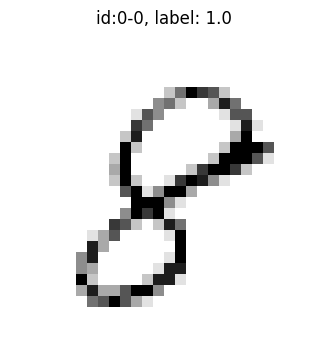

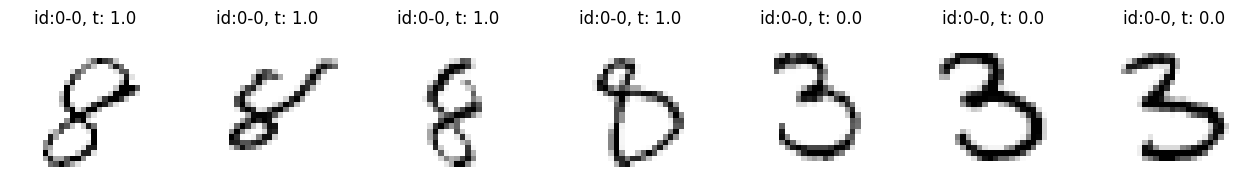

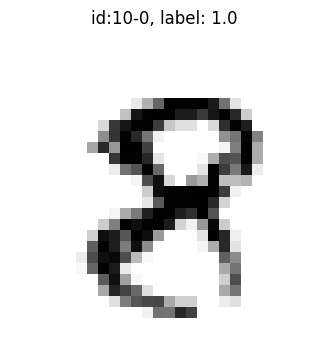

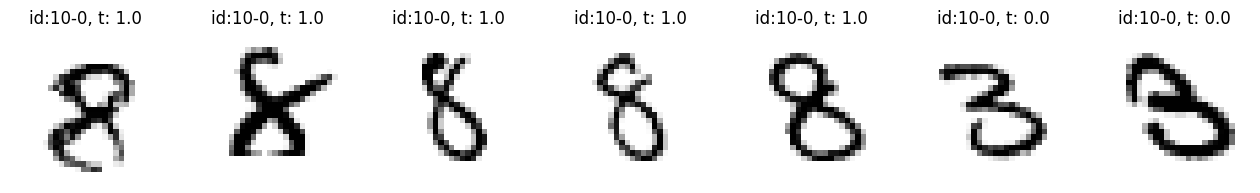

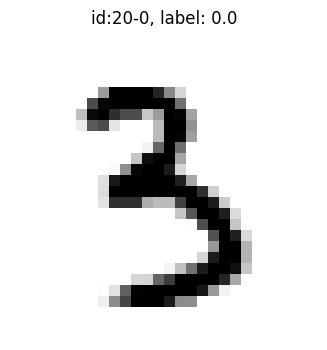

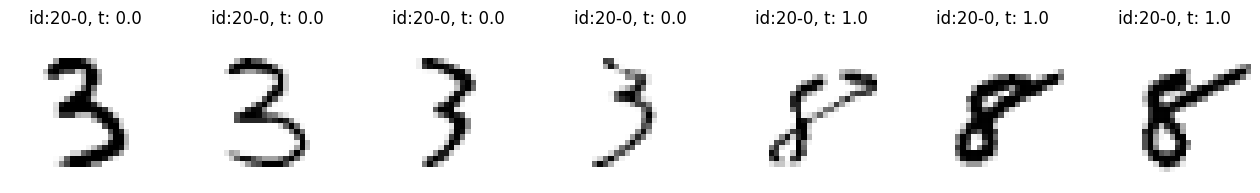

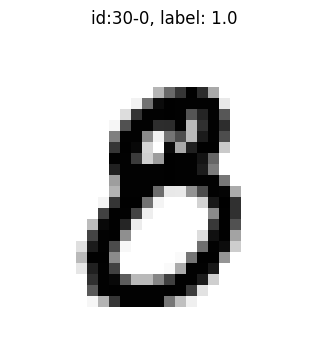

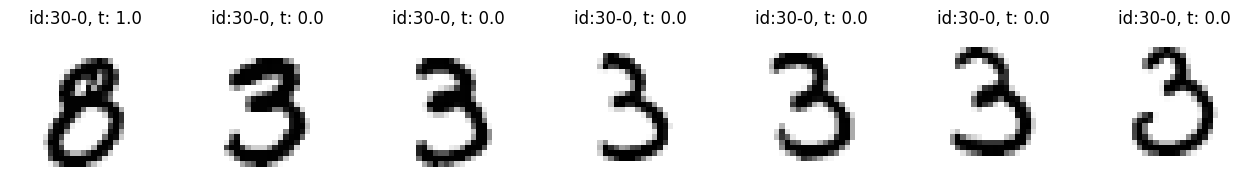

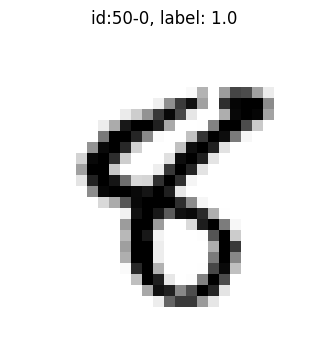

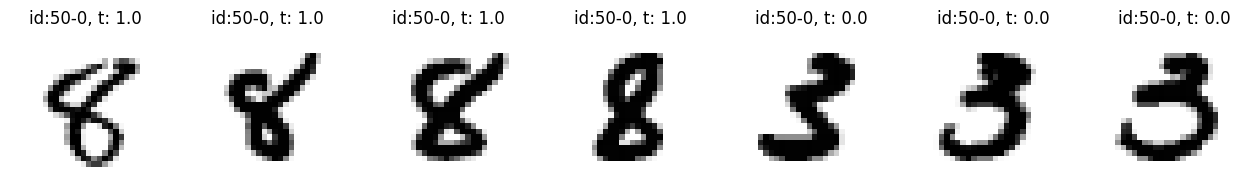

In [10]:
for k in res.keys():
    for k2 in res[k].keys():
        print(k, k2)
        plot_digits(X[k],y[k],'-'.join(map(str, [k, k2])))
        plot_counterfactuals(X,y,res[k][k2], '-'.join(map(str, [k, k2])))

## Pseudo-code

- train classifier - use density estimation to generate paths

- train second classifier using cf dataset?
    - how to implement loss?
    - clone standard method and add direction loss to loss?


In [11]:
plot_digits(np.arange(1050,1070),0)

TypeError: plot_digits() missing 1 required positional argument: '_id'

In [ ]:
plot_digits(np.arange(1810,1815),0)
